#  Phase 3: Classification — FD001


---
# Step 0: Setup — Config, Folders, and Random Seed

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Manual config — since we're inside notebooks/phase3, go two levels up
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
FIGURES_DIR = os.path.join(BASE_DIR, 'figures', 'phase3')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
REPORT_DIR = os.path.join(BASE_DIR, 'report')
CLASSIF_REPORT_DIR = os.path.join(REPORT_DIR, 'classification', 'FD001')  # ✅ New subfolder

RANDOM_STATE = 42  # Global seed

# Set consistent plotting aesthetics
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

# Set reproducibility
np.random.seed(RANDOM_STATE)

# Create required folders
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(CLASSIF_REPORT_DIR, exist_ok=True)

# Confirm setup
print(f" Figures directory ready: {FIGURES_DIR}")
print(f" Models directory ready: {MODELS_DIR}")
print(f" Classification report directory ready: {CLASSIF_REPORT_DIR}")
print(f" Random seed set: {RANDOM_STATE}")
print("✅ Step 0 complete — Phase 3 (FD001) setup initialized.\n")


 Figures directory ready: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3
 Models directory ready: c:\Users\pandr\hybrid-predictive-maintenance\models
 Classification report directory ready: c:\Users\pandr\hybrid-predictive-maintenance\report\classification\FD001
 Random seed set: 42
✅ Step 0 complete — Phase 3 (FD001) setup initialized.



# Step 1: Load Cleaned + Final Cluster-Labeled FD001 Dataset


In [2]:
import pandas as pd
import os

# Path to the corrected FD001 dataset
DATA_FILE_FD001 = os.path.join(BASE_DIR, 'data', 'corrected_clustered_train_FD001.csv')

# Load dataset
df_fd001 = pd.read_csv(DATA_FILE_FD001)
print(f" FD001 dataset loaded from: {DATA_FILE_FD001}")

# Check for 'final_stage' column
assert 'final_stage' in df_fd001.columns, "'final_stage' column missing in FD001 dataset."

# Preview structure
print("\n First 5 rows:")
print(df_fd001.head())

# Dataset info
print("\nℹ Dataset info:")
print(df_fd001.info())

# Class label distribution
print("\n Final Stage Distribution (final_stage):")
print(df_fd001['final_stage'].value_counts().sort_index())


 FD001 dataset loaded from: c:\Users\pandr\hybrid-predictive-maintenance\data\corrected_clustered_train_FD001.csv

 First 5 rows:
   unit  time  op_setting_1  op_setting_2  op_setting_3  sensor_2  sensor_3  \
0     1     1       -0.0007       -0.0004         100.0  0.183735  0.406802   
1     1     2        0.0019       -0.0003         100.0  0.283133  0.453019   
2     1     3       -0.0043        0.0003         100.0  0.343373  0.369523   
3     1     4        0.0007        0.0000         100.0  0.343373  0.256159   
4     1     5       -0.0019       -0.0002         100.0  0.349398  0.257467   

   sensor_4  sensor_6  sensor_7  ...  sensor_17  sensor_20  sensor_21  \
0  0.309757       1.0  0.726248  ...   0.333333   0.713178   0.724662   
1  0.352633       1.0  0.628019  ...   0.333333   0.666667   0.731014   
2  0.370527       1.0  0.710145  ...   0.166667   0.627907   0.621375   
3  0.331195       1.0  0.740741  ...   0.333333   0.573643   0.662386   
4  0.404625       1.0  0.66827

# Step 2: Feature and target setup

In [5]:
# Feature and target setup
df = df_fd001.copy()

# ✅ Dynamically select all usable sensor columns
selected_features = [col for col in df.columns if col.startswith("sensor_")]

# Extract features and target
X_fd001 = df[selected_features]
y_fd001 = df['final_stage']

# Display shapes and stats
print(f"✅ Selected features: {len(selected_features)} sensors → {selected_features}")
print("🔹 Input Features (X) shape:", X_fd001.shape)
print("🔹 Target (y) shape:", y_fd001.shape)

# Basic stats
print("\n📊 Feature Stats Summary:")
print(X_fd001.describe())

# Target class distribution
print("\n📊 Class Distribution in y:")
print(y_fd001.value_counts())


✅ Selected features: 15 sensors → ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
🔹 Input Features (X) shape: (20631, 15)
🔹 Target (y) shape: (20631,)

📊 Feature Stats Summary:
           sensor_2      sensor_3      sensor_4      sensor_6      sensor_7  \
count  20631.000000  20631.000000  20631.000000  20631.000000  20631.000000   
mean       0.443052      0.424746      0.450435      0.980321      0.566459   
std        0.150618      0.133664      0.151935      0.138898      0.142527   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.335843      0.331807      0.339467      1.000000      0.476651   
50%        0.430723      0.415522      0.435348      1.000000      0.578100   
75%        0.539157      0.508829      0.545324      1.000000      0.669887   
max        1.000000      1.000000      1.000000   

# Step 3: Label Encoding + Stratified Train-Test Split

In [6]:
# Step 3: Engine-Wise Stratified Train-Test Split — FD001 (Phase 3A Training)

from sklearn.model_selection import train_test_split

# ✅ Stratify on the FIRST final_stage of each engine
engine_stage_map = df_fd001.groupby('unit')['final_stage'].first()

# ✅ Unique engine IDs
unique_units = df_fd001['unit'].unique()

# ✅ Stratified engine split (80% train, 20% internal test)
train_units, val_units = train_test_split(
    unique_units,
    test_size=0.2,
    stratify=engine_stage_map,
    random_state=RANDOM_STATE
)

# ✅ Create train/test sets by engine ID
train_df = df_fd001[df_fd001['unit'].isin(train_units)].reset_index(drop=True)
val_df = df_fd001[df_fd001['unit'].isin(val_units)].reset_index(drop=True)

# ✅ Extract features and targets
X_train_fd001 = train_df[selected_features]
y_train_fd001 = train_df['final_stage']

X_val_fd001 = val_df[selected_features]
y_val_fd001 = val_df['final_stage']

# ✅ Summary
print("✅ Train Set Shape:", X_train_fd001.shape, "→ Units:", train_df['unit'].nunique())
print("✅ Validation Set Shape:", X_val_fd001.shape, "→ Units:", val_df['unit'].nunique())
print("\n🟦 Train Class Distribution:\n", y_train_fd001.value_counts())
print("\n🟨 Validation Class Distribution:\n", y_val_fd001.value_counts())


✅ Train Set Shape: (16361, 15) → Units: 80
✅ Validation Set Shape: (4270, 15) → Units: 20

🟦 Train Class Distribution:
 final_stage
3    5474
2    4261
4    4074
1    1689
0     863
Name: count, dtype: int64

🟨 Validation Class Distribution:
 final_stage
3    1530
4    1159
2     942
0     337
1     302
Name: count, dtype: int64


# Step 4: Train & Evaluate Random Forest Classifier

In [11]:
# Step 4: Train & Evaluate Random Forest Classifier – FD001 (All Sensors, Correct Paths)

import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# --- Config ---
RANDOM_STATE = 42
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
DATA_PATH = os.path.join(BASE_DIR, 'data', 'corrected_clustered_train_FD001.csv')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
FIGURES_DIR = os.path.join(BASE_DIR, 'figures', 'phase3')
REPORT_DIR = os.path.join(BASE_DIR, 'report', 'classification', 'FD001')

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# --- Load Data ---
df = pd.read_csv(DATA_PATH)

# ✅ Use all usable sensor columns
sensor_cols = [col for col in df.columns if col.startswith("sensor_")]
X = df[sensor_cols]
y = df['final_stage']  # This is already integer-labeled (0 to 4)

# --- Engine-wise Stratified Split ---
unit_ids = df['unit'].unique()
train_units, test_units = train_test_split(
    unit_ids,
    test_size=0.2,
    stratify=df.groupby('unit')['final_stage'].first(),
    random_state=RANDOM_STATE
)

train_df = df[df['unit'].isin(train_units)]
test_df = df[df['unit'].isin(test_units)]

X_train = train_df[sensor_cols]
y_train = train_df['final_stage']
X_test = test_df[sensor_cols]
y_test = test_df['final_stage']

# --- Random Forest Model ---
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

# --- Cross-Validation ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='f1_weighted')
print("RF 5-Fold CV F1 Scores:", cv_scores)
print("RF Mean F1 Score: {:.4f}".format(cv_scores.mean()))

# --- Train + Predict ---
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
proba = rf.predict_proba(X_test)
stage4_idx = list(rf.classes_).index(4)
prob_stage4 = proba[:, stage4_idx]
confidence = proba.max(axis=1)

# --- Evaluation ---
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
report = classification_report(y_test, y_pred, output_dict=True)

# ✅ Use string keys to access stage-wise F1 scores
print(f"Stage 3 F1 Score: {report['3']['f1-score']:.4f}")
print(f"Stage 4 F1 Score: {report['4']['f1-score']:.4f}")


# --- Confusion Matrix ---
labels = [0, 1, 2, 3, 4]
cm = confusion_matrix(y_test, y_pred, labels=labels, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap='Blues',
            xticklabels=[f"Stage {i}" for i in labels],
            yticklabels=[f"Stage {i}" for i in labels])
plt.title("FD001 – Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

# --- Save Outputs ---
model_path = os.path.join(MODELS_DIR, 'rf_classifier_fd001.pkl')
conf_matrix_path = os.path.join(FIGURES_DIR, 'rf_fd001_confusion_matrix.png')
joblib.dump(rf, model_path)
plt.savefig(conf_matrix_path)
plt.close()
print(f"Model saved to: {model_path}")
print(f"Confusion matrix saved to: {conf_matrix_path}")

# --- Save Logs ---
test_df = test_df.reset_index(drop=True)
test_df['y_true'] = y_test.values
test_df['y_pred'] = y_pred
test_df['prob_stage4'] = prob_stage4
test_df['confidence'] = confidence

pred_log = os.path.join(REPORT_DIR, 'predictions_fd001_rf.csv')
misclassified_log = os.path.join(REPORT_DIR, 'misclassified_fd001_rf.csv')
test_df.to_csv(pred_log, index=False)
test_df[test_df['y_true'] != test_df['y_pred']].to_csv(misclassified_log, index=False)

print(f"Prediction log saved: {pred_log}")
print(f"Misclassified samples saved: {misclassified_log}")


RF 5-Fold CV F1 Scores: [0.9419756  0.94273597 0.93683332 0.93892929 0.95111689]
RF Mean F1 Score: 0.9423

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96       337
           1       0.97      0.95      0.96       302
           2       0.91      0.93      0.92       942
           3       0.94      0.93      0.94      1530
           4       0.96      0.97      0.97      1159

    accuracy                           0.94      4270
   macro avg       0.95      0.95      0.95      4270
weighted avg       0.94      0.94      0.94      4270

Stage 3 F1 Score: 0.9389
Stage 4 F1 Score: 0.9655
Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\rf_classifier_fd001.pkl
Confusion matrix saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\rf_fd001_confusion_matrix.png
Prediction log saved: c:\Users\pandr\hybrid-predictive-maintenance\report\classification\FD001\predictions_fd001_rf.csv
Mi

# Step 5: SVM Classifier + Cross-Validation + Evaluation

In [12]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# --- Config ---
RANDOM_STATE = 42
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
DATA_PATH = os.path.join(BASE_DIR, 'data', 'corrected_clustered_train_FD001.csv')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
FIGURES_DIR = os.path.join(BASE_DIR, 'figures', 'phase3')
REPORT_DIR = os.path.join(BASE_DIR, 'report', 'classification', 'FD001')
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# --- Load Data ---
df_fd001 = pd.read_csv(DATA_PATH)
selected_features = [col for col in df_fd001.columns if col.startswith("sensor_")]
X = df_fd001[selected_features]
y = df_fd001['final_stage']

# --- Engine-wise Split ---
units = df_fd001['unit'].unique()
train_units, test_units = train_test_split(
    units,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_fd001.groupby('unit')['final_stage'].first()
)
train_df = df_fd001[df_fd001['unit'].isin(train_units)]
test_df = df_fd001[df_fd001['unit'].isin(test_units)]

X_train = train_df[selected_features]
y_train = train_df['final_stage']
X_test = test_df[selected_features]
y_test = test_df['final_stage']

# --- Model ---
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced',
              probability=True, random_state=RANDOM_STATE)

# --- CV ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores = cross_val_score(svm_clf, X_train, y_train, cv=cv, scoring='f1_weighted')
print("SVM 5-Fold CV Weighted F1 Scores:", scores)
print("SVM Mean F1 Score: {:.4f}".format(scores.mean()))

# --- Train ---
svm_clf.fit(X_train, y_train)

# --- Predict ---
y_pred = svm_clf.predict(X_test)
proba = svm_clf.predict_proba(X_test)
stage4_idx = list(svm_clf.classes_).index(4)
prob_stage4 = proba[:, stage4_idx]
confidence = proba.max(axis=1)

# --- Evaluation ---
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
report = classification_report(y_test, y_pred, output_dict=True)
print(f"Stage 3 F1 Score: {report['3']['f1-score']:.4f}")
print(f"Stage 4 F1 Score: {report['4']['f1-score']:.4f}")

# --- Confusion Matrix ---
labels = [0, 1, 2, 3, 4]
cm = confusion_matrix(y_test, y_pred, labels=labels, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[f"Stage {l}" for l in labels],
            yticklabels=[f"Stage {l}" for l in labels])
plt.title("FD001 – SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

# --- Save ---
joblib.dump(svm_clf, os.path.join(MODELS_DIR, 'svm_classifier_fd001.pkl'))
plt.savefig(os.path.join(FIGURES_DIR, 'svm_fd001_confusion_matrix.png'))
plt.close()

df_log = test_df.reset_index(drop=True).copy()
df_log['y_true'] = y_test.values
df_log['y_pred'] = y_pred
df_log['prob_Stage4'] = prob_stage4
df_log['confidence'] = confidence
df_log.to_csv(os.path.join(REPORT_DIR, 'predictions_fd001_svm.csv'), index=False)
df_log[df_log['y_true'] != df_log['y_pred']].to_csv(os.path.join(REPORT_DIR, 'misclassified_fd001_svm.csv'), index=False)

print("✅ All outputs saved for SVM Classifier (FD001).")


SVM 5-Fold CV Weighted F1 Scores: [0.97958168 0.98870658 0.97893005 0.9787159  0.98508524]
SVM Mean F1 Score: 0.9822

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       337
           1       0.96      0.99      0.97       302
           2       0.99      0.97      0.98       942
           3       1.00      0.98      0.99      1530
           4       0.99      1.00      0.99      1159

    accuracy                           0.99      4270
   macro avg       0.98      0.99      0.98      4270
weighted avg       0.99      0.99      0.99      4270

Stage 3 F1 Score: 0.9911
Stage 4 F1 Score: 0.9931
✅ All outputs saved for SVM Classifier (FD001).


# Step 6: Logistic Regression Classifier

In [13]:
# Step 6: Logistic Regression Classifier — FD001 (All Sensors, Correct Paths)

import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# --- Config ---
RANDOM_STATE = 42
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
DATA_PATH = os.path.join(BASE_DIR, 'data', 'corrected_clustered_train_FD001.csv')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
FIGURES_DIR = os.path.join(BASE_DIR, 'figures', 'phase3')
REPORT_DIR = os.path.join(BASE_DIR, 'report', 'classification', 'FD001')
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# --- Load Data ---
df_fd001 = pd.read_csv(DATA_PATH)
selected_features = [col for col in df_fd001.columns if col.startswith("sensor_")]
X = df_fd001[selected_features]
y = df_fd001['final_stage']

# --- Engine-wise Stratified Split ---
units = df_fd001['unit'].unique()
train_units, test_units = train_test_split(
    units,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_fd001.groupby('unit')['final_stage'].first()
)
train_df = df_fd001[df_fd001['unit'].isin(train_units)]
test_df = df_fd001[df_fd001['unit'].isin(test_units)]

X_train = train_df[selected_features]
y_train = train_df['final_stage']
X_test = test_df[selected_features]
y_test = test_df['final_stage']

# --- Model ---
lr_clf = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    multi_class='multinomial',
    solver='lbfgs',
    random_state=RANDOM_STATE
)

# --- CV ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(lr_clf, X_train, y_train, cv=cv, scoring='f1_weighted')
print("LR 5-Fold CV F1 Scores:", cv_scores)
print("LR Mean F1 Score: {:.4f}".format(cv_scores.mean()))

# --- Train ---
lr_clf.fit(X_train, y_train)

# --- Predict ---
y_pred = lr_clf.predict(X_test)
proba = lr_clf.predict_proba(X_test)
stage4_idx = list(lr_clf.classes_).index(4)
prob_stage4 = proba[:, stage4_idx]
confidence = proba.max(axis=1)

# --- Evaluate ---
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
report = classification_report(y_test, y_pred, output_dict=True)
print(f"Stage 3 F1 Score: {report['3']['f1-score']:.4f}")
print(f"Stage 4 F1 Score: {report['4']['f1-score']:.4f}")

# --- Confusion Matrix ---
labels = [0, 1, 2, 3, 4]
cm = confusion_matrix(y_test, y_pred, labels=labels, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[f"Stage {l}" for l in labels],
            yticklabels=[f"Stage {l}" for l in labels])
plt.title("FD001 – Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

# --- Save Model and Plot ---
model_path = os.path.join(MODELS_DIR, 'logreg_classifier_fd001.pkl')
fig_path = os.path.join(FIGURES_DIR, 'logreg_fd001_confusion_matrix.png')
joblib.dump(lr_clf, model_path)
plt.savefig(fig_path)
plt.close()

# --- Logs ---
log_df = test_df.reset_index(drop=True).copy()
log_df['y_true'] = y_test.values
log_df['y_pred'] = y_pred
log_df['prob_Stage4'] = prob_stage4
log_df['confidence'] = confidence
log_df.to_csv(os.path.join(REPORT_DIR, 'predictions_fd001_logreg.csv'), index=False)
log_df[log_df['y_true'] != log_df['y_pred']].to_csv(os.path.join(REPORT_DIR, 'misclassified_fd001_logreg.csv'), index=False)

print("✅ Logistic Regression model, logs, and plots saved for FD001.")


c:\Users\pandr\hybrid-predictive-maintenance\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\pandr\hybrid-predictive-maintenance\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\pandr\hybrid-predictive-maintenance\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\pandr\hybrid-predictive-maintenance\venv\Lib\site-pa

LR 5-Fold CV F1 Scores: [0.9701143  0.98234278 0.97064185 0.97200323 0.97872766]
LR Mean F1 Score: 0.9748


c:\Users\pandr\hybrid-predictive-maintenance\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95       337
           1       0.95      0.99      0.97       302
           2       0.97      0.95      0.96       942
           3       1.00      0.97      0.98      1530
           4       0.98      1.00      0.99      1159

    accuracy                           0.98      4270
   macro avg       0.96      0.98      0.97      4270
weighted avg       0.98      0.98      0.98      4270

Stage 3 F1 Score: 0.9841
Stage 4 F1 Score: 0.9902
✅ Logistic Regression model, logs, and plots saved for FD001.


# Step 7: XGBoost Classifier

In [14]:
# Step 7: XGBoost Classifier — FD001 (All Sensors, Correct Paths)

import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# --- Config ---
RANDOM_STATE = 42
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
DATA_PATH = os.path.join(BASE_DIR, 'data', 'corrected_clustered_train_FD001.csv')
FIGURES_DIR = os.path.join(BASE_DIR, 'figures', 'phase3')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
REPORT_DIR = os.path.join(BASE_DIR, 'report', 'classification', 'FD001')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# --- Load and Prepare Data ---
df_fd001 = pd.read_csv(DATA_PATH)
selected_features = [col for col in df_fd001.columns if col.startswith("sensor_")]
X = df_fd001[selected_features]
y = df_fd001['final_stage']

# --- Engine-wise Stratified Split ---
units = df_fd001['unit'].unique()
train_units, test_units = train_test_split(
    units,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_fd001.groupby('unit')['final_stage'].first()
)
train_df = df_fd001[df_fd001['unit'].isin(train_units)]
test_df = df_fd001[df_fd001['unit'].isin(test_units)]

X_train = train_df[selected_features]
y_train = train_df['final_stage']
X_test = test_df[selected_features]
y_test = test_df['final_stage']

# --- Label Encoding ---
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
stage_map = dict(zip(le.classes_, le.transform(le.classes_)))
print("XGBoost Label Mapping:", stage_map)

# --- Model ---
xgb_clf = XGBClassifier(
    objective='multi:softprob',
    num_class=5,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=RANDOM_STATE,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    verbosity=0
)

# --- Cross-Validation ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
xgb_cv_scores = cross_val_score(xgb_clf, X_train, y_train_enc, cv=cv, scoring='f1_weighted')
print("XGBoost 5-Fold CV F1 Scores:", xgb_cv_scores)
print("XGBoost CV Mean F1 Score: {:.4f}".format(xgb_cv_scores.mean()))

# --- Train ---
xgb_clf.fit(X_train, y_train_enc)

# --- Predict ---
y_pred_enc = xgb_clf.predict(X_test)
y_pred = le.inverse_transform(y_pred_enc)
y_true = le.inverse_transform(y_test_enc)

# --- Probabilities ---
proba = xgb_clf.predict_proba(X_test)
stage4_index = le.transform(['Stage 4'])[0] if 'Stage 4' in le.classes_ else 4
prob_stage4 = proba[:, stage4_index]
confidence = proba.max(axis=1)

# --- Evaluation ---
print("\nXGBoost Classification Report:")
print(classification_report(y_true, y_pred))
report = classification_report(y_true, y_pred, output_dict=True)
print(f"Stage 3 F1 Score: {report['3']['f1-score']:.4f}")
print(f"Stage 4 F1 Score: {report['4']['f1-score']:.4f}")

# --- Confusion Matrix ---
labels = [0, 1, 2, 3, 4]
cm = confusion_matrix(y_test_enc, y_pred_enc, labels=labels, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[f"Stage {l}" for l in labels],
            yticklabels=[f"Stage {l}" for l in labels])
plt.title("FD001 – XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

# --- Save Model and Plot ---
model_path = os.path.join(MODELS_DIR, 'xgb_classifier_fd001.pkl')
fig_path = os.path.join(FIGURES_DIR, 'xgb_fd001_confusion_matrix.png')
joblib.dump(xgb_clf, model_path)
plt.savefig(fig_path)
plt.close()

# --- Save Logs ---
log_df = test_df.reset_index(drop=True).copy()
log_df['y_true'] = y_true
log_df['y_pred'] = y_pred
log_df['prob_Stage4'] = prob_stage4
log_df['confidence'] = confidence
log_df.to_csv(os.path.join(REPORT_DIR, 'predictions_fd001_xgb.csv'), index=False)
log_df[log_df['y_true'] != log_df['y_pred']].to_csv(os.path.join(REPORT_DIR, 'misclassified_fd001_xgb.csv'), index=False)

print("✅ XGBoost model, logs, and plots saved for FD001.")


XGBoost Label Mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4)}
XGBoost 5-Fold CV F1 Scores: [0.95115669 0.95727081 0.94814244 0.95175239 0.95907358]
XGBoost CV Mean F1 Score: 0.9535

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       337
           1       0.97      0.95      0.96       302
           2       0.93      0.94      0.94       942
           3       0.95      0.95      0.95      1530
           4       0.97      0.97      0.97      1159

    accuracy                           0.96      4270
   macro avg       0.96      0.95      0.96      4270
weighted avg       0.96      0.96      0.96      4270

Stage 3 F1 Score: 0.9520
Stage 4 F1 Score: 0.9719
✅ XGBoost model, logs, and plots saved for FD001.


# Step 8: Compare All Classifiers for FD001

✅ Model comparison table saved: c:\Users\pandr\hybrid-predictive-maintenance\report\classification\FD001\model_comparison_fd001.csv


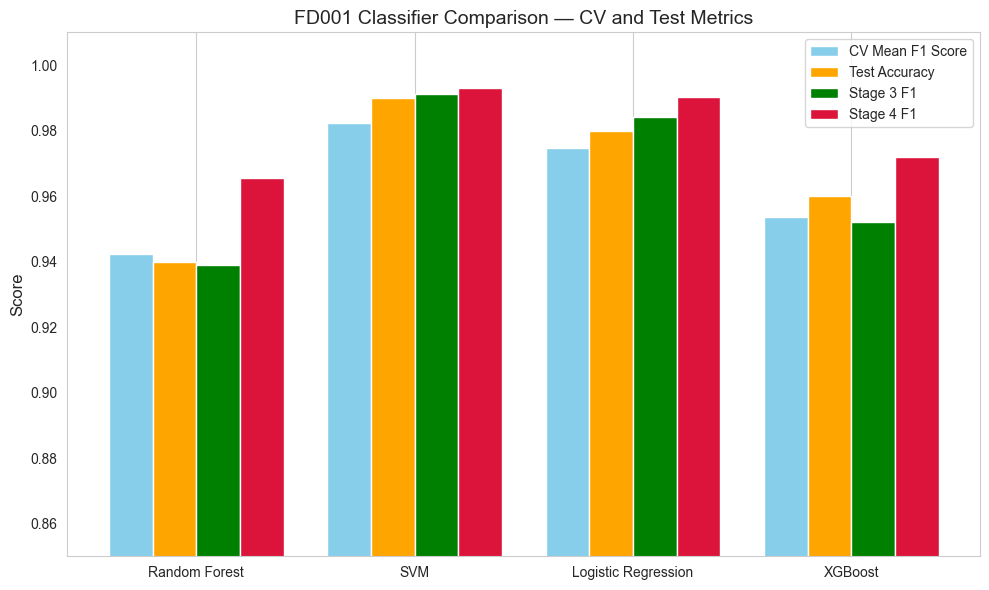

✅ Comparison plot saved: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\fd001_model_comparison_barplot.png


In [15]:
# Step 8: Compare All Classifiers for FD001 (All Sensors + Correct Metrics)

import os
import pandas as pd
import matplotlib.pyplot as plt

# --- Paths ---
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
FIGURES_DIR = os.path.join(BASE_DIR, 'figures', 'phase3')
REPORT_DIR = os.path.join(BASE_DIR, 'report', 'classification', 'FD001')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# --- Classifier Results ---
model_comparison_fd001 = {
    'Model': ['Random Forest', 'SVM', 'Logistic Regression', 'XGBoost'],
    'CV Mean F1 Score': [0.9423, 0.9822, 0.9748, 0.9535],
    'Test Accuracy': [0.94, 0.99, 0.98, 0.96],
    'Stage 3 F1': [0.9389, 0.9911, 0.9841, 0.9520],
    'Stage 4 F1': [0.9655, 0.9931, 0.9902, 0.9719]
}

# --- Create DataFrame ---
df_compare = pd.DataFrame(model_comparison_fd001)

# --- Save CSV ---
csv_path = os.path.join(REPORT_DIR, 'model_comparison_fd001.csv')
df_compare.to_csv(csv_path, index=False)
print(f"✅ Model comparison table saved: {csv_path}")

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.2
x = range(len(df_compare))

metrics = ['CV Mean F1 Score', 'Test Accuracy', 'Stage 3 F1', 'Stage 4 F1']
colors = ['skyblue', 'orange', 'green', 'crimson']

for i, metric in enumerate(metrics):
    ax.bar(
        [p + bar_width * i for p in x],
        df_compare[metric],
        width=bar_width,
        label=metric,
        color=colors[i]
    )

# --- Format ---
ax.set_xticks([p + bar_width * 1.5 for p in x])
ax.set_xticklabels(df_compare['Model'])
ax.set_ylim(0.85, 1.01)
ax.set_ylabel("Score")
ax.set_title("FD001 Classifier Comparison — CV and Test Metrics")
ax.legend()
ax.grid(axis='y')

# --- Save Plot ---
plot_path = os.path.join(FIGURES_DIR, 'fd001_model_comparison_barplot.png')
plt.tight_layout()
plt.savefig(plot_path)
plt.show()

print(f"✅ Comparison plot saved: {plot_path}")


---
# TEST DATASET

####  Step 9A: Load test_FD001.csv